# **LINEAR ELASTICITY, MATERIAL ROBUSTNESS & BGG**

<!-- 2D rectangular beam. Fixed on the left and right face, traction-free on the top and bottom.

Two Hellinger–Reissner mixed schemes are implemented and can be selected at runtime:
- **JM** (Johnson–Mercier): symmetric $P_1$ stress in $H(\operatorname{div})$, $P_0$ displacement.
- **AFW** (Arnold–Falk–Winther): $[BDM_1]^2$ stress with *weakly imposed* symmetry, $P_0$ displacement, scalar $DG_0$ skew-rotation variable $\gamma$. -->

## **Imports**

In [1]:
try:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-development-real.sh" -O "/tmp/firedrake-install.sh"
    !bash "/tmp/firedrake-install.sh"
    from firedrake import *  # noqa: F401
except:
    from firedrake import *  # noqa: F401

--2026-07-10 16:21:01--  https://fem-on-colab.github.io/releases/firedrake-install-development-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4876 (4.8K) [application/x-sh]
Saving to: ‘/tmp/firedrake-install.sh’

/tmp/firedrake-inst 100%[===================>]   4.76K  --.-KB/s    in 0s      

2026-07-10 16:21:02 (52.5 MB/s) - ‘/tmp/firedrake-install.sh’ saved [4876/4876]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FIREDRAKE_INSTALLED=/usr/local/share/fem-on-colab/firedrake.installed
+ [[ ! -f /usr/local/share/fem-on-colab/firedrake.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/

In [2]:
import matplotlib.pyplot as plt

## **Functions**

In [41]:
def solve_elasticity(scheme="JM", length=10.0, height=1.0, nu=0.3, nx=20, ny=20, shear=1.0, grav=0.0, free_surf=(3,4)):
    # Mesh
    mesh = RectangleMesh(nx, ny, length, height)
    x, y = SpatialCoordinate(mesh)
    d = 2

    # Material parameters
    nu_c  = Constant(nu)
    mu    = 1 / (2*(1 + nu_c))
    lmbda = nu_c / ((1 + nu_c) * (1 - 2*nu_c))
    def A_comp(s):
        # Compliance tensor
        return (1/(2*mu))*sym(s) - (lmbda/(2*mu*(2*mu + d*lmbda)))*tr(s)*Identity(d)

    # Function spaces + functions
    if scheme == "JM":
        JM = FunctionSpace(mesh, "JM", 1)
        DG_vec = VectorFunctionSpace(mesh, "DG", 0, variant="alfeld")
        W  = JM * DG_vec
        sigma, u_0 = TrialFunctions(W)
        tau,   v   = TestFunctions(W)
    elif scheme == "AFW":
        AFW_elem = VectorElement(FiniteElement("BDM", mesh.ufl_cell(), 1, variant="alfeld"), dim=2)
        AFW = FunctionSpace(mesh, AFW_elem, variant="alfeld")
        DG_vec = VectorFunctionSpace(mesh, "DG", 0, variant="alfeld")
        DG = FunctionSpace(mesh, "DG", 0, variant="alfeld")
        W = AFW * DG_vec * DG
        sigma, u_0, gamma = TrialFunctions(W)
        tau,   v,   eta   = TestFunctions(W)
    elif scheme == "PEERS":
        PEERS_elem = VectorElement(FiniteElement("RT", mesh.ufl_cell(), 1), dim=2)
        PEERS = FunctionSpace(mesh, PEERS_elem)
        bubble = VectorFunctionSpace(mesh, "B", 3)
        DG_vec = VectorFunctionSpace(mesh, "DG", 0)
        CG = FunctionSpace(mesh, "CG", 1)
        W = PEERS * bubble * DG_vec * CG
        sigma_core, sigma_bubble, u_0, gamma = TrialFunctions(W)
        tau_core,   tau_bubble,   v,   eta   = TestFunctions(W)
        def reconstruct_tensor(core, bubble):
            return core + as_tensor([curl(bubble[i]) for i in range(2)])
        sigma = reconstruct_tensor(sigma_core, sigma_bubble)
        tau   = reconstruct_tensor(tau_core,   tau_bubble)
    else:
        raise ValueError(f"Unknown scheme '{scheme}'. Choose 'JM', 'AFW' or 'PEERS'.")

    # LHS
    a = (
        inner(A_comp(sigma), tau)
      + inner(u_0, div(tau))
      + inner(div(sigma), v)
    ) * dx
    if (scheme == "AFW") or (scheme == "PEERS"):
        def asym2d(tau): return tau[0, 1] - tau[1, 0]
        a += (
            inner(gamma, asym2d(tau))
          + inner(asym2d(sigma), eta)
        ) * dx

    # RHS
    x_var = variable(x)
    phi = - shear/2 * cos(pi * x_var / length)
    phi_prime = diff(phi, x_var)
    u_BC = as_vector([(y - height/2) * phi_prime, phi])
    L = (
        inner(sym(grad(u_BC)), tau)
      + grav * inner(as_vector([0,1]), v)
    ) * dx

    # Boundary conditions
    bcs = [
        DirichletBC(W.sub(0), 0, surf)
        for surf in free_surf
    ]

    # Solve
    w = Function(W)
    solve(a == L, w, bcs=bcs)

    # Output
    if scheme == "JM":
        sigma, u_0 = w.subfunctions[0:2]
    elif scheme == "AFW":
        sigma, u_0, gamma = w.subfunctions[0:3]
    elif scheme == "PEERS":
        sigma_core, sigma_bubble, u_0, gamma = w.subfunctions[0:4]
        sigma = reconstruct_tensor(sigma_core, sigma_bubble)

    s00 = sigma[0, 0]
    s11 = sigma[1, 1]
    s01 = (sigma[0, 1] + sigma[1, 0]) / 2
    sig_vm = sqrt(s00**2 - s00*s11 + s11**2 + 3*s01**2)
    sig_vm_dg = Function(FunctionSpace(mesh, "DG", 0), name="Von Mises stress (DG0)").project(sig_vm)
    sig_vm_cg = Function(FunctionSpace(mesh, "CG", 1), name="Von Mises stress (CG1)").project(sig_vm)

    u = Function(DG_vec, name="u (DG0)").project(u_BC + u_0)
    u_cg = Function(VectorFunctionSpace(mesh, "CG", 1), name="u (CG1)").project(u)

    if scheme == "JM":
        return sigma, (u, u_cg), (sig_vm_dg, sig_vm_cg), mesh
    elif scheme == "AFW":
        return sigma, (u, u_cg), (sig_vm_dg, sig_vm_cg), mesh, gamma
    elif scheme == "PEERS":
        return sigma, (u, u_cg), (sig_vm_dg, sig_vm_cg), mesh, gamma

In [7]:
def plot_solution(u_cg, sig_vm_cg, mesh):
    """Plot vertical displacement and von Mises stress."""
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    # Vertical displacement
    c0 = tripcolor(u_cg.sub(1), axes=axes[0], cmap="RdBu_r")
    plt.colorbar(c0, ax=axes[0], label=r"$u_y$")
    # axes[0].set_aspect("equal")
    axes[0].set_title("Vertical displacement")

    # Von Mises stress
    c1 = tripcolor(sig_vm_cg, axes=axes[1], cmap="inferno")
    plt.colorbar(c1, ax=axes[1], label=r"$\sigma_\mathrm{vM}$")
    # axes[1].set_aspect("equal")
    axes[1].set_title("Von Mises stress")

    plt.tight_layout()
    plt.show()

In [8]:
def plot_deformation(u_cg, sig_vm_dg, mesh):
    """Plot deformed mesh (coloured by von Mises stress)."""
    import matplotlib.pyplot as plt
    import matplotlib.tri as mtri

    coords = mesh.coordinates.dat.data_ro
    cells  = mesh.coordinates.cell_node_map().values
    disp   = u_cg.dat.data_ro

    triang_ref = mtri.Triangulation(coords[:, 0], coords[:, 1], cells)
    triang_def = mtri.Triangulation(
        coords[:, 0] + disp[:, 0],
        coords[:, 1] + disp[:, 1],
        cells,
    )

    fig, ax = plt.subplots(figsize=(10, 3))
    tc = ax.tripcolor(triang_def, facecolors=sig_vm_dg.dat.data_ro, cmap="inferno")
    plt.colorbar(tc, ax=ax, label=r"$\sigma_\mathrm{vM}$")
    ax.triplot(triang_ref, color="k", linewidth=0.3, alpha=0.2, label="Original")
    # ax.set_aspect("equal")
    ax.legend()
    ax.set_title(f"Deformed mesh (von Mises stress)")

    plt.tight_layout()
    plt.show()

In [9]:
def diagnostics(sigma, mesh, length, height, gamma=None, show=True):
    """Print resultant forces on the left (clamped) and right (free) faces."""
    n = FacetNormal(mesh)
    scale = (length/height)**3
    if show: print(BLUE % f"Scaled forces:")
    for label, marker in [(" Left", 1), ("Right", 2)]:
        Fx = scale * assemble(dot(sigma, n)[0] * ds(marker))
        Fy = scale * assemble(dot(sigma, n)[1] * ds(marker))
        if show: print(BLUE % f"  • {label} = ({Fx:+.6g}, {Fy:+.6g})")

    print()

    if gamma is not None:
        gamma_norm = sqrt(assemble(inner(gamma, gamma) * dx) / (length * height))
        # if show: print(RED % f"Normalised gamma norm = {gamma_norm:.6g}")
        return Fx, Fy, gamma_norm
    else:
        return Fx, Fy

In [22]:
def run_and_plot(scheme="JM", params=None):
    if scheme not in {"JM", "AFW", "PEERS"}:
        raise ValueError(f"Unknown scheme '{scheme}'. Choose 'JM', 'AFW' or 'PEERS'.")
    if scheme=="JM":
        sigma, (u, u_cg), (sig_vm_dg, sig_vm_cg), mesh = solve_elasticity("JM", **params)
    elif scheme=="AFW":
        sigma, (u, u_cg), (sig_vm_dg, sig_vm_cg), mesh, gamma = solve_elasticity("AFW", **params)
    elif scheme=="PEERS":
        sigma, (u, u_cg), (sig_vm_dg, sig_vm_cg), mesh, gamma = solve_elasticity("PEERS", **params)
    # plot_solution(u_cg, sig_vm_cg, mesh)
    plot_deformation(u_cg, sig_vm_dg, mesh)
    if scheme=="JM":
        diagnostics(sigma, mesh, params["length"], params["height"])
    elif scheme=="AFW":
        diagnostics(sigma, mesh, params["length"], params["height"], gamma=gamma)
    elif scheme=="PEERS":
        diagnostics(sigma, mesh, params["length"], params["height"], gamma=gamma)

In [46]:
def find_stress(scheme="JM", params=None):
    if scheme not in {"JM", "AFW", "PEERS"}:
        raise ValueError(f"Unknown scheme '{scheme}'. Choose 'JM', 'AFW' or 'PEERS'.")
    output = solve_elasticity(scheme, **params)
    diag = diagnostics(output[0], output[3], params["length"], params["height"], show=False)
    return diag[1]

## **Shear / Bending test**

In [12]:
model_params = {
    "length" : 5.0,
    "height" : 1.0,
    "nu" : 0.3,
}

disc_params = {
    "nx" : 10,
    "ny" : 10,
}

params = model_params | disc_params

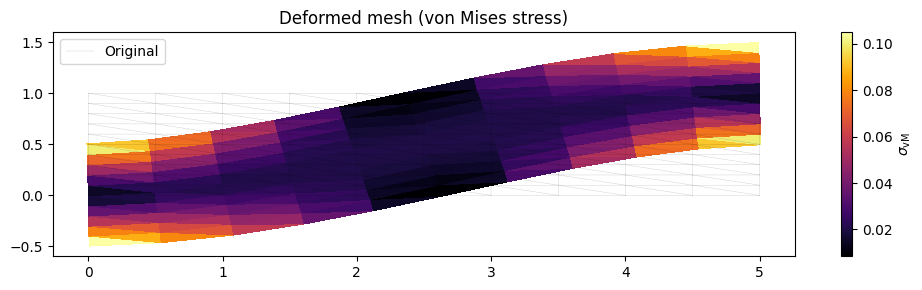

Scaled forces:
  •  Left = (+0.00298016, -0.97237)
  • Right = (-0.00298016, +0.97237)



In [13]:
run_and_plot(scheme="JM", params=params)

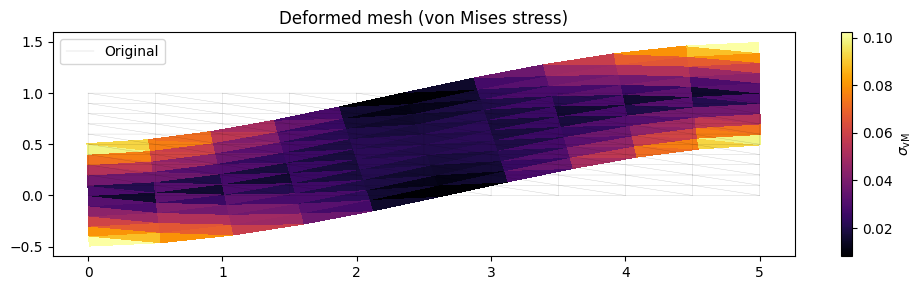

Scaled forces:
  •  Left = (-0.00159297, -1.0438)
  • Right = (+0.00159297, +1.0438)



In [14]:
run_and_plot(scheme="AFW", params=params)

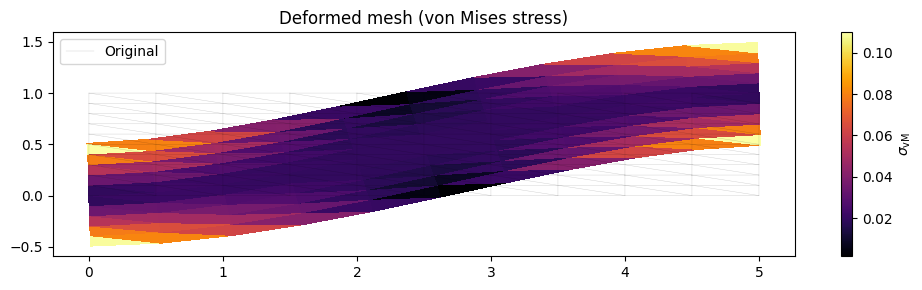

Scaled forces:
  •  Left = (+0.00650056, -0.944832)
  • Right = (-0.00650056, +0.944832)



In [42]:
run_and_plot(scheme="PEERS", params=params)

Some simple elasticity theory tell us the shear force on the ends of the beam scale like

$$
    \mathbf{F}\cdot\mathbf{e}_2 \propto \frac{\varepsilon H^3}{L^3}.
$$

- More strain $\implies$ More stress
- Thicker beam $\implies$ (Much) more stress
- Long beam $\implies$ (Much) less stress

All very intuitive!
"Scaled forces" thus evaluates

$$
    \frac{L^3}{\varepsilon H^3}\mathbf{F},
$$

which should converge.
So let's try making the beam longer...

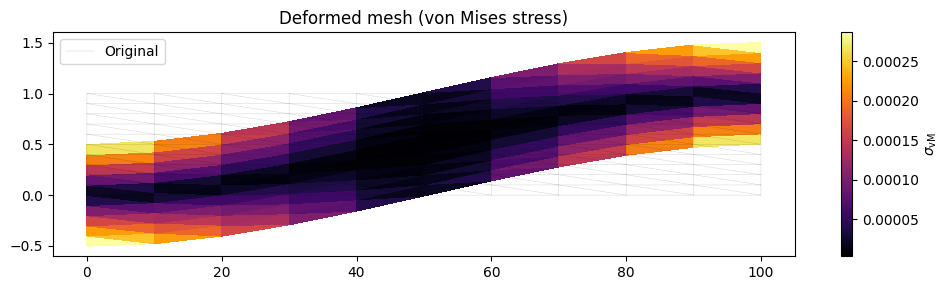

Scaled forces:
  •  Left = (+3.92303e-06, -1.0983)
  • Right = (-3.92302e-06, +1.0983)



In [19]:
run_and_plot(scheme="JM", params=params|{"length":100.0})

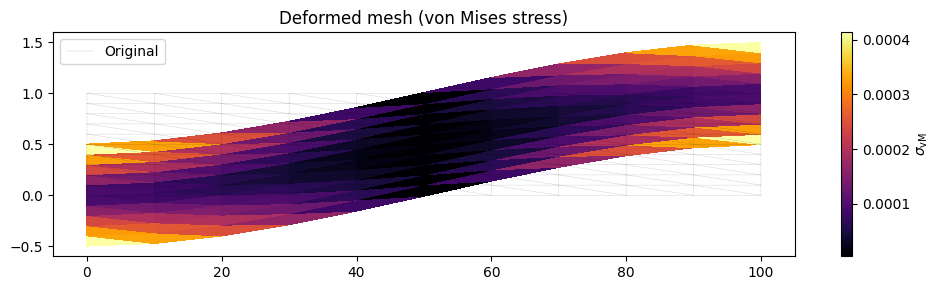

Scaled forces:
  •  Left = (+0.00612603, -3.10698)
  • Right = (-0.00612603, +3.10698)



In [20]:
run_and_plot(scheme="AFW", params=params|{"length":100.0})

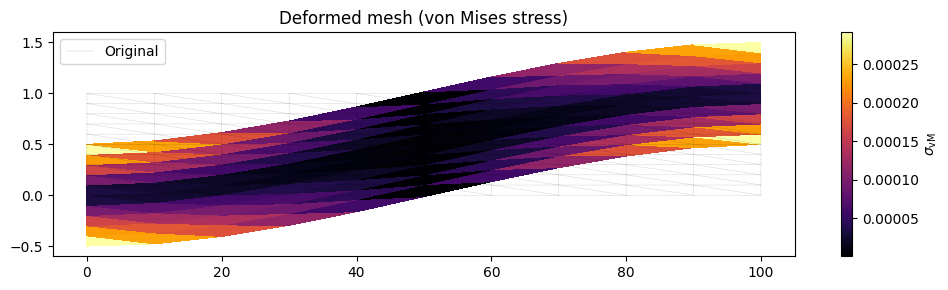

Scaled forces:
  •  Left = (+0.000288213, -1.06925)
  • Right = (-0.000288213, +1.06925)



In [43]:
run_and_plot(scheme="PEERS", params=params|{"length":100.0})

These shear stresses are very different? Maybe they're converging, but to different limits?

Let's try a bunch of different lengths...

In [44]:
length_arr = [10.0**(i/5) for i in range(0,16)]

Starting AFW tests...

Solving at length 1.0...

Solving at length 1.6...

Solving at length 2.5...

Solving at length 4.0...

Solving at length 6.3...

Solving at length 10.0...

Solving at length 15.8...

Solving at length 25.1...

Solving at length 39.8...

Solving at length 63.1...

Solving at length 100.0...

Solving at length 158.5...

Solving at length 251.2...

Solving at length 398.1...

Solving at length 631.0...

Solving at length 1000.0...

Starting JM tests...

Solving at length 1.0...

Solving at length 1.6...

Solving at length 2.5...

Solving at length 4.0...

Solving at length 6.3...

Solving at length 10.0...

Solving at length 15.8...

Solving at length 25.1...

Solving at length 39.8...

Solving at length 63.1...

Solving at length 100.0...

Solving at length 158.5...

Solving at length 251.2...

Solving at length 398.1...

Solving at length 631.0...

Solving at length 1000.0...

Starting PEERS tests...

Solving at length 1.0...

Solving at length 1.6...

Solving at

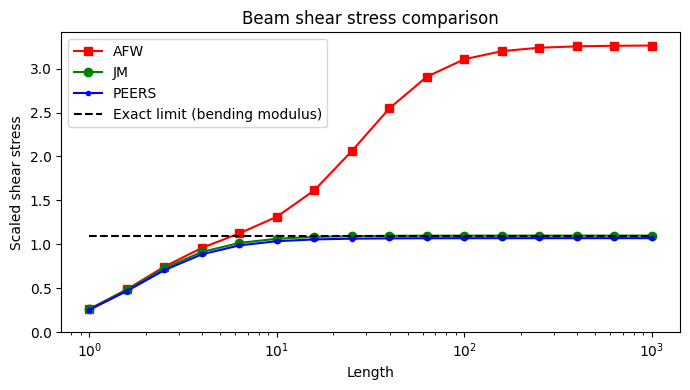

In [47]:
results = {scheme: [] for scheme in ("AFW", "JM", "PEERS")}
for scheme in ("AFW", "JM", "PEERS"):
    print(BLUE % f"Starting {scheme} tests...\n")
    for length in length_arr:
        print(GREEN % f"Solving at length {length:.1f}...")
        results[scheme].append(find_stress(scheme=scheme, params=params|{"length":length}))

fig, ax = plt.subplots(figsize=(7, 4))
for scheme, color, marker in (("AFW", "red", "s"), ("JM", "green", "o"), ("PEERS", "blue", ".")):
    ax.plot(length_arr, results[scheme], color=color, marker=marker, label=scheme)
bend_mod = 1 / (1 - params["nu"]**2)
ax.plot([length_arr[0], length_arr[-1]], [bend_mod, bend_mod], "--", color="black", marker="none", label="Exact limit (bending modulus)")
ax.set_xscale("log")
ax.set_xlabel("Length")
ax.set_ylim(bottom=0)
ax.set_ylabel(r"Scaled shear stress")
ax.set_title("Beam shear stress comparison")
ax.legend()

plt.tight_layout()
plt.show()

We can actually solve exactly for the limit in this simple model:

$$
    \mathbf{F}\cdot\mathbf{e}_2 \sim \frac{1}{1 - \nu^2}\cdot\frac{\varepsilon H^3}{L^3}.
$$

Plotting this limit in the above figure, we see JM greatly outperforms AFW.

- AFW (weakly symmetric) is much more stiff under bending than it should be
- JM (strongly symmetric) is not

*Why is this?*